In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from gammapy.modeling.models import (
    Models,
    PointSpatialModel,
    PowerLawNormSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpatialModel,
    create_fermi_isotropic_diffuse_model,
)
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL
from astropy.coordinates import SkyCoord
import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [2]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/fermi_config_rcw86_celestial_6years.yaml', logging={'verbosity': 3})

2025-05-08 09:56:40 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [3]:
gta.config

{'logging': {'prefix': '', 'chatter': 3, 'verbosity': 3},
 'fileio': {'outdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years',
  'scratchdir': '/scratch',
  'workdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years',
  'logfile': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years/fermipy.log',
  'savefits': True,
  'workdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$'],
  'outdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$|\\.png$|\\.pdf$|\\.yaml$'],
  'usescratch': False},
 'optimizer': {'optimizer': 'MINUIT',
  'tol': 0.001,
  'max_iter': 100,
  'init_lambda': 0.0001,
  'retries': 3,
  'min_fit_quality': 2,
  'verbosity': 0},
 'binning': {'projtype': 'WCS',
  'proj': 'AIT',
  'coordsys': 'CEL',
  'npix': None,
  'roiwidth': 4.0,
  'binsz': 0.02,
  'binsperdec': 8.0,
  'enumbins': None,
  'hpx_ordering_scheme': 'RING',
  'hpx_order': 10,


In [4]:
gta.setup()

2025-05-08 09:56:44 INFO    GTAnalysis.setup(): Running setup.
2025-05-08 09:56:44 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-08 09:56:44 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-08 09:56:44 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-05-08 09:56:44 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set MJD-OBS to 54683.000000 from DATE-OBS.
Set MJD-END to 57074.333310 from DATE-END'. [astropy.wcs.wcs]
2025-05-08 09:56:44 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-05-08 09:56:44 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-05-08 09:56:44 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-05-08 09:56:47 INFO    GTAnalysis.setup(): Initializing source properties
2025-05-08 09:56:49 INFO    GTAnalysis.setup(): Finished setup.


2025-05-07 22:32:08 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years/initial_00.xml...
2025-05-07 22:32:08 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years/initial.fits...
2025-05-07 22:32:10 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-07 22:32:11 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years/initial.npy...


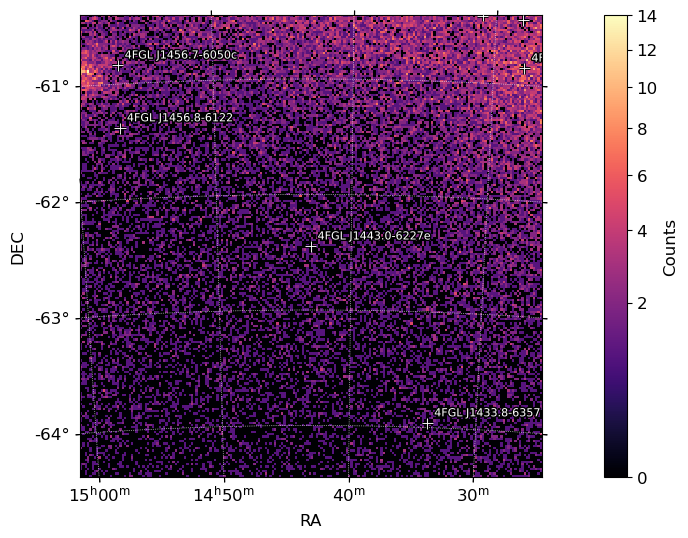

In [5]:
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

In [6]:
gta.print_model()

2025-05-07 22:32:12 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.000   1.695  1.33e-05   1.47       nan       134.0     
4FGL J1433.8-6357      1.834   1.790  1.06e-06   2.70       nan        98.1     
4FGL J1456.8-6122      1.942   1.083  9.92e-07   2.26       nan        52.5     
4FGL J1456.7-6050c     2.290   1.338  2.39e-06   1.42       nan        18.9     
4FGL J1427.8-6051      2.409   2.795   8.5e-06   2.62       nan       583.4     
4FGL J1430.9-6024c     2.493   1.309  1.85e-06   2.82       nan        96.0     
4FGL J1428.0-6026c     2.689   0.633   3.4e-06   3.38       nan       188.6     
isodiff                  ---   1.000    0.0313   2.12       nan       591.5     
galdiff                  ---   1.000     0.132   0.00       nan     36523.7     



In [7]:
gta.free_sources()

2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1443.0-6227e    : ['Prefactor', 'Index']
2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1433.8-6357     : ['norm', 'alpha', 'beta']
2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.8-6122     : ['Prefactor', 'Index']
2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.7-6050c    : ['Prefactor', 'Index']
2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1427.8-6051     : ['norm', 'alpha', 'beta']
2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1430.9-6024c    : ['norm', 'alpha', 'beta']
2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1428.0-6026c    : ['norm', 'alpha', 'beta']
2025-05-07 22:32:12 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2

In [8]:
from gammapy.catalog import SourceCatalog4FGL

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [9]:
source_rcw86 = catalog_4fgl["4FGL J1443.0-6227e"]

In [10]:
source_rcw86.data

{'Source_Name': '4FGL J1443.0-6227e',
 'DataRelease': 1,
 'RAJ2000': <Quantity 220.76 deg>,
 'DEJ2000': <Quantity -62.45 deg>,
 'GLON': <Quantity 315.4419 deg>,
 'GLAT': <Quantity -2.3204007 deg>,
 'Conf_68_SemiMajor': <Quantity 0. deg>,
 'Conf_68_SemiMinor': <Quantity 0. deg>,
 'Conf_68_PosAng': <Quantity 0. deg>,
 'Conf_95_SemiMajor': <Quantity 0. deg>,
 'Conf_95_SemiMinor': <Quantity 0. deg>,
 'Conf_95_PosAng': <Quantity 0. deg>,
 'ROI_num': 761,
 'Extended_Source_Name': 'RCW 86            ',
 'Signif_Avg': 15.167515,
 'Pivot_Energy': <Quantity 31680.906 MeV>,
 'Flux1000': <Quantity 5.1422167e-10 1 / (s cm2)>,
 'Unc_Flux1000': <Quantity 7.6599706e-11 1 / (s cm2)>,
 'Energy_Flux100': <Quantity 9.22062e-12 erg / (s cm2)>,
 'Unc_Energy_Flux100': <Quantity 9.564077e-13 erg / (s cm2)>,
 'SpectrumType': 'PowerLaw         ',
 'PL_Flux_Density': <Quantity 1.6952421e-15 1 / (MeV s cm2)>,
 'Unc_PL_Flux_Density': <Quantity 1.671159e-16 1 / (MeV s cm2)>,
 'PL_Index': 1.4709476,
 'Unc_PL_Index':

### Free parameters around roi center with distance 3 deg.

In [5]:
gta.free_sources(free=False)
# Around particular source 
#gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)
gta.free_sources(distance=[3.0],free=True)
gta.print_model()

2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1443.0-6227e    : ['Prefactor', 'Index']
2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1433.8-6357     : ['norm', 'alpha', 'beta']
2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.8-6122     : ['Prefactor', 'Index']
2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1456.7-6050c    : ['Prefactor', 'Index']
2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1427.8-6051     : ['norm', 'alpha', 'beta']
2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1430.9-6024c    : ['norm', 'alpha', 'beta']
2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1428.0-6026c    : ['norm', 'alpha', 'beta']
2025-05-08 09:56:58 INFO    GTAnalysis.free_source(): Freeing parameters for isodiff               : ['Normalization']
2

In [6]:
gta.fit()

2025-05-08 09:57:01 INFO    GTAnalysis.fit(): Starting fit.


Drm_Cache::update Measured counts < 0 4FGL J1428.0-6026c 21 -8.54708e-12 7.90018e-11
34.1226 24.6949 16.1285 9.49751 5.06132 2.44595 1.08263 0.442278 0.162949 0.0546154 0.0166277 0.00462108 0.00117228 0.000271076 5.65047e-05 1.07256e-05 1.85844e-06 2.94868e-07 4.29133e-08 5.73806e-09 7.04392e-10 7.90018e-11 


2025-05-08 09:57:03 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-08 09:57:03 INFO    GTAnalysis.fit(): LogLike:  -103105.452 DeltaLogLike:      315.052 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 315.05222210937063,
 'edm': 0.00026669475524567556,
 'loglike': -103105.45181459634,
 'covariance': array([[ 9.67398117e-02, -2.00107636e-02,  1.23740832e-02,
         -8.78291638e-03,  7.73909286e-03,  2.45137442e-07,
          5.18318874e-04,  3.74635495e-03, -1.75721042e-03,
          3.77387906e-04, -2.53429386e-03, -1.81600831e-03,
          1.83816989e-04,  2.16514361e-04,  4.17502560e-04,
         -4.12543285e-04,  8.59213777e-04, -3.03079939e-05,
         -2.76739419e-04,  3.87610018e-04, -1.82219703e-02],
        [-2.00107636e-02,  1.55508088e-02, -4.67023975e-03,
         -3.75008631e-03, -2.48688782e-02, -3.39075399e-07,
         -1.77320304e-03, -7.45060192e-03,  2.98786088e-03,
         -1.27777341e-03,  2.12019140e-03,  7.02771189e-04,
         -2.43839846e-04,  1.15363326e-04, -2.28504563e-04,
          3.14364809e-04,  1.16393430e-04, -3.68144691e-04,
         -1.62533128e-04, -2.02547198e-04,  1.11

In [7]:
gta.print_model()

2025-05-08 09:57:12 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1443.0-6227e     0.000   1.751  1.37e-05   1.48     79.95       139.7    *
4FGL J1433.8-6357      1.834   1.494  8.44e-07   2.87     11.44        82.2    *
4FGL J1456.8-6122      1.942   2.896  2.33e-06   2.57     33.60       176.2    *
4FGL J1456.7-6050c     2.290   0.237  1.07e-05   3.33    561.40      1091.9    *
4FGL J1427.8-6051      2.409   2.595  1.12e-05   2.87    186.78       724.9    *
4FGL J1430.9-6024c     2.493   1.520  2.48e-06   2.68      8.50       116.8    *
4FGL J1428.0-6026c     2.689   0.659  2.56e-06   4.82     12.86       146.6    *
isodiff                  ---   1.450    0.0454   2.12     16.11       857.6    *
galdiff                  ---   0.933     0.122   0.00  39706.61     33958.8    *



In [8]:
plt.clf()
tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True, exclude = gta.roi.sources[0].name)

2025-05-08 09:57:25 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-08 09:57:26 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-08 09:58:17 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-08 09:58:20 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-08 09:58:20 INFO    GTAnalysis.tsmap(): Execution time: 54.21 s


<Figure size 640x480 with 0 Axes>

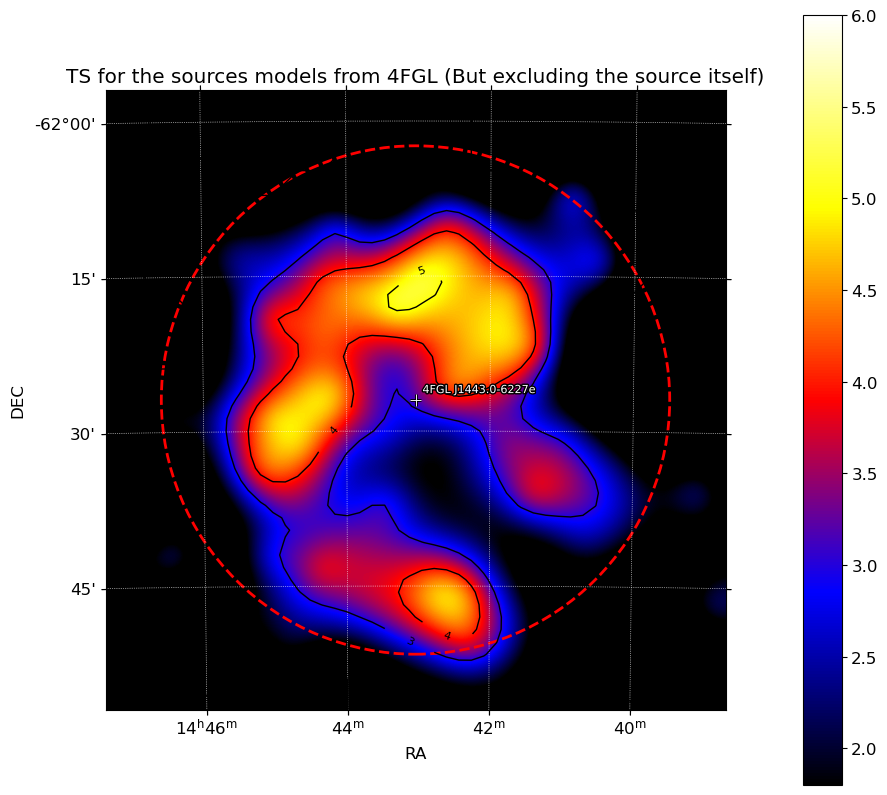

In [11]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               label_ts_threshold=10.0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=4,vmin=1.8,vmax=6, levels=[0,3,4,5,6])
from astropy.coordinates import SkyCoord

circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.41,  # radius in degrees
              skydir=circle_pos,
              edgecolor='red',
              linewidth=2.0,
              linestyle='--')
plt.title("TS for the sources models from 4FGL (But excluding the source itself)")
plt.show()

In [14]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-05-07 22:32:13 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-07 22:32:13 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-07 22:33:12 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-07 22:33:15 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-07 22:33:15 INFO    GTAnalysis.tsmap(): Execution time: 61.84 s


<Figure size 640x480 with 0 Axes>

In [15]:
gta.print_roi()

2025-05-07 22:33:15 INFO    GTAnalysis.print_roi(): 
name                SpatialModel   SpectrumType     offset        ts       npred
--------------------------------------------------------------------------------
4FGL J1443.0-6227e  SpatialMap     PowerLaw          0.000     78.58       126.2
4FGL J1433.8-6357   PointSource    LogParabola       1.834      8.15        62.8
4FGL J1456.8-6122   PointSource    PowerLaw          1.942    132.81       459.3
4FGL J1456.7-6050c  PointSource    PowerLaw          2.290       nan        18.9
4FGL J1427.8-6051   PointSource    LogParabola       2.409       nan       583.4
4FGL J1430.9-6024c  PointSource    LogParabola       2.493       nan        96.0
4FGL J1428.0-6026c  PointSource    LogParabola       2.689       nan       188.6
isodiff             ConstantValue  FileFunction      -----     11.23       734.2
galdiff             MapCubeFunctio PowerLaw          -----  37240.38     35023.0



<Figure size 640x480 with 0 Axes>

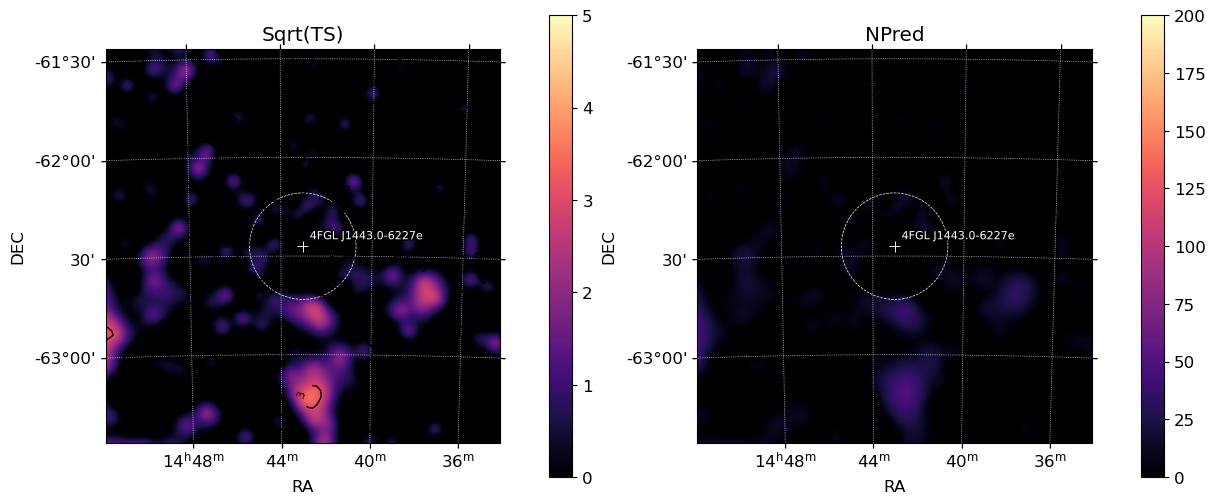

In [16]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

In [17]:
plt.clf()
tsmap_excluded = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True, exclude = gta.roi.sources[0].name)

2025-05-07 22:33:15 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-07 22:33:16 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-07 22:34:16 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-07 22:34:19 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial_6years/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-07 22:34:19 INFO    GTAnalysis.tsmap(): Execution time: 63.85 s


<Figure size 640x480 with 0 Axes>

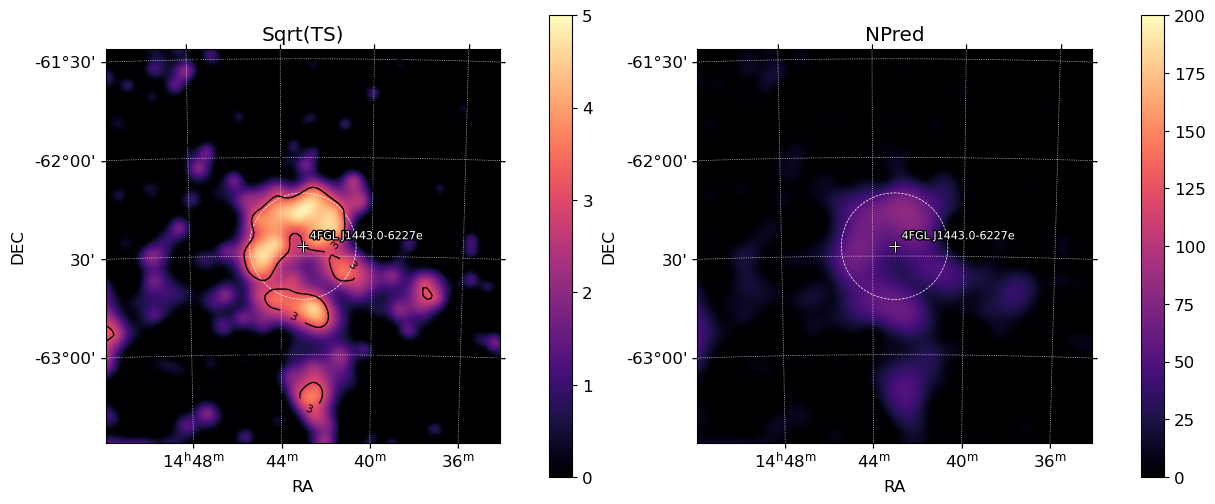

In [18]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_excluded['sqrt_ts'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',levels=[0,3,5,7],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 2)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_excluded['npred'],roi=gta.roi, graticule_radii=[0.27]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 2)
plt.gca().set_title('NPred')
plt.show()

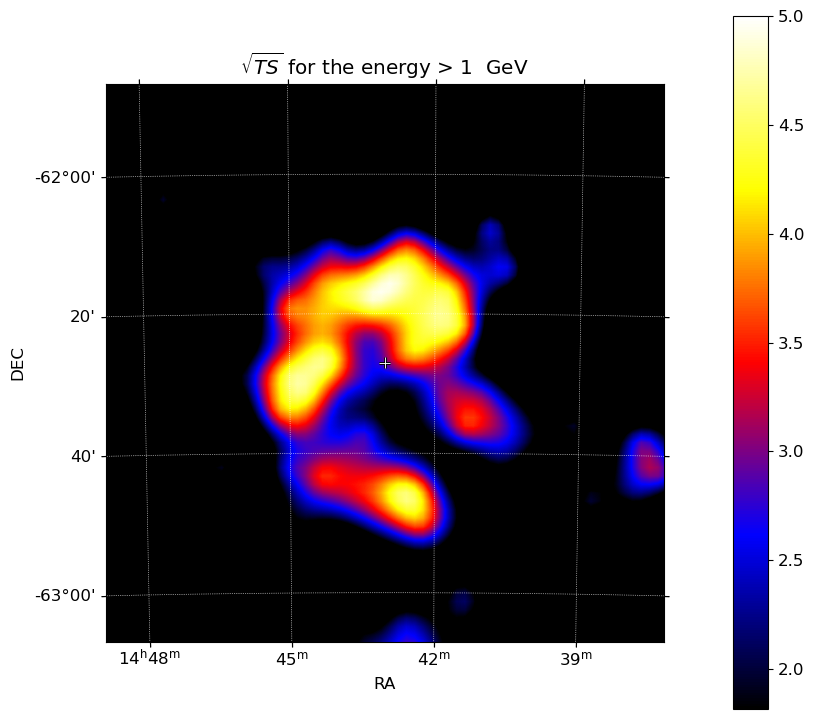

In [19]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               #graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=1000.0)  # optional threshold for labeling
plt.figure(figsize=(9, 9))
#p.plot(interpolation='bicubic', zoom=3,vmin=3.3,vmax=7.5, levels=[0,3,4,5,6,7,8])
p.plot(interpolation='bilinear', zoom=3,vmin=3.3**0.5,vmax=5)#, levels=[0,3,4,5,6], )
#p.plot(interpolation='bicubic', zoom=3,vmin=3.3,vmax=7)


snr_rcw_86 = SkyCoord(gta.roi.sources[0].radec[0],gta.roi.sources[0].radec[1], unit="deg", frame="icrs")


# p.draw_circle(0.27,  # radius in degrees
#               skydir=snr_rcw_86,
#               edgecolor='cyan',
#               linewidth=2.0,
#               linestyle='--')
plt.title("$\sqrt{TS}$ for the energy > 1  GeV")
plt.show()

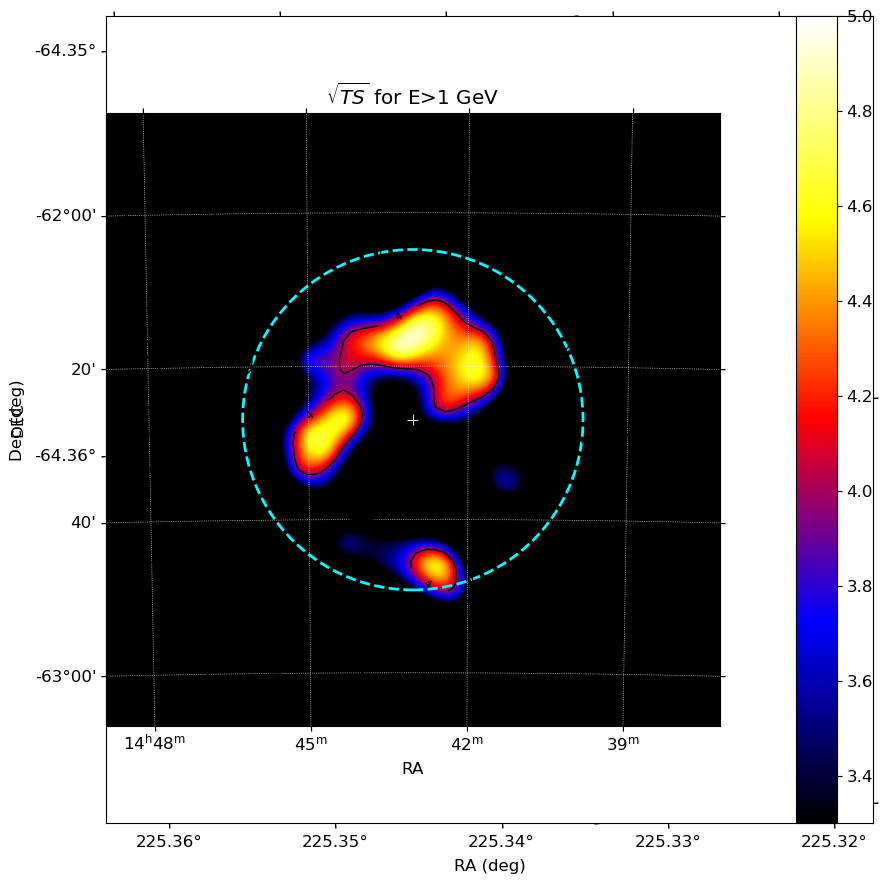

In [20]:
import matplotlib.pyplot as plt
from astropy import units as u

# 1) Prepare your map & ROIPlotter as before
tsmap = tsmap_excluded['sqrt_ts']
p = ROIPlotter(tsmap, roi=gta.roi, cmap='ds9_b',
               label_ts_threshold=1000.0)

# 2) Create a WCS‐aware Axes
fig = plt.figure(figsize=(9, 9))
ax  = fig.add_subplot(111, projection=tsmap.geom.wcs)

# 3) Plot into that axis
p.plot(interpolation='bicubic',
       zoom=3,
       vmin=3.3,
       vmax=5,
       levels=[0,3,4,5,6,7,8],
       ax=ax)

# 4) Draw your circle as before
snr_rcw_86 = SkyCoord(gta.roi.sources[0].radec[0],
                      gta.roi.sources[0].radec[1],
                      unit="deg", frame="icrs")

p.draw_circle(0.37,
              skydir=snr_rcw_86,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--',
              ax=ax)

# 5) Switch the axis format to degrees
lon = ax.coords['ra']
lat = ax.coords['dec']

# Force degrees (instead of H:M:S)
lon.set_format_unit(u.deg)
lat.set_format_unit(u.deg)

# Choose a simple decimal formatter, e.g. 2 decimals
lon.set_major_formatter('d.dd')
lat.set_major_formatter('d.dd')

# Relabel
lon.set_axislabel('RA (deg)')
lat.set_axislabel('Dec (deg)')

plt.title(r"$\sqrt{TS}$ for E>1 GeV")
plt.tight_layout()
plt.show()

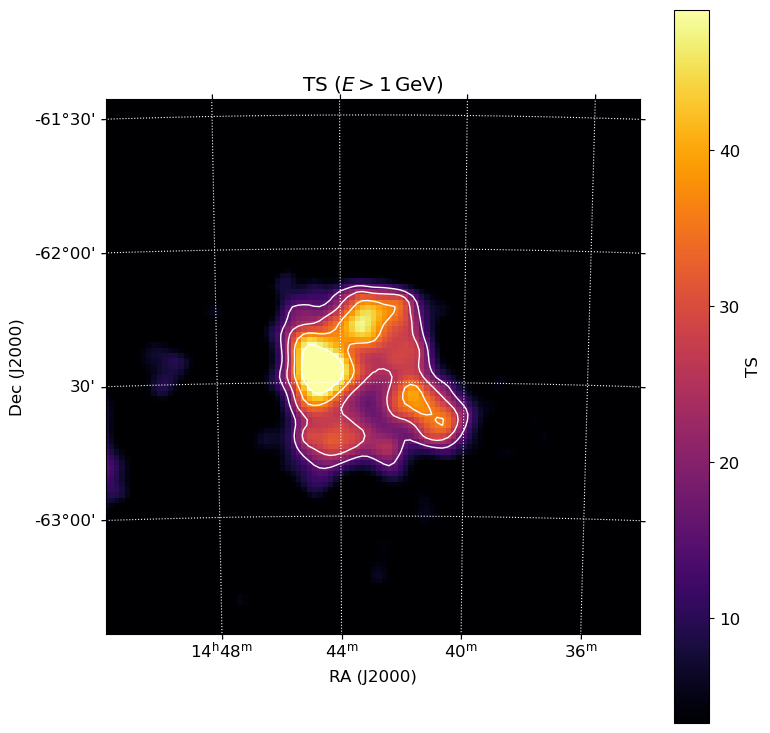

In [21]:
from astropy.io import fits
from astropy.wcs import WCS
import matplotlib.pyplot as plt

# 1. Open your TS‑map FITS (make sure it's the file on disk!)
hdu  = fits.open('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/TSmap_start_pointsource_powerlaw_2.00_tsmap.fits')[0]

wcs = WCS(hdu.header)              # header from their FITS file
fig = plt.figure(figsize=(8,8))
ax  = fig.add_subplot(111, projection=wcs)  # TAN by default

im = ax.imshow(hdu.data, origin='lower',
          interpolation='nearest',  # no smoothing
          cmap='inferno', vmin=3.3, vmax=49)
# 4. Overlay your TS contours
levels = [16,25,36, 49]
ax.contour(hdu.data,
           levels=levels,
           transform=ax.get_transform(wcs),
           colors='white',
           linewidths=1)

# 5. Cosmetic labels
ax.set_xlabel('RA (J2000)')
ax.set_ylabel('Dec (J2000)')
ax.coords.grid(True, color='white', ls='dotted')
plt.title(r'TS $(E>1\rm\,GeV)$')
plt.colorbar(im, label=r'TS')
ax.set_xlim(50, 150)
ax.set_ylim(50, 150)
plt.tight_layout()
plt.show()

In [22]:
# from gammapy.maps import Map
# import matplotlib.pyplot as plt

# m = Map.read('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/TSmap_start_pointsource_powerlaw_2.00_tsmap.fits')
# fig, ax = plt.subplots(subplot_kw={'projection': m.geom.wcs}, figsize=(8, 8))

# im = m.plot(ax=ax, cmap='ds9_b', add_cbar=False, vmin=3.3, vmax=8)
# levels = [3,4,5,6,7,8]
# m.plot_contour(ax=ax, levels=levels, colors='white')

# ax.set_xlabel('RA (J2000)')
# ax.set_ylabel('Dec (J2000)')
# plt.colorbar(im, ax=ax, label=r'$\sqrt{\mathrm{TS}}$')
# plt.tight_layout()
# plt.show()



import aplpy

fig = aplpy.FITSFigure('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/rcw86/output_rcw_celestial/TSmap_start_pointsource_powerlaw_2.00_tsmap.fits', figsize=(8,8))
fig.show_colorscale(vmin=3.3, vmax=8, cmap='ds9_b')
fig.show_contour('tsmap_excluded_sqrt_ts.fits', levels=[3,4,5,6,7,8], colors='white')
fig.add_colorbar()
fig.add_grid(color='white', ls='dotted')
fig.axis_labels.set_xtext('RA (J2000)')
fig.axis_labels.set_ytext('Dec (J2000)')
fig.set_title(r'$\sqrt{\mathrm{TS}}\ (E>1\rm\,GeV)$')
plt.show()

ModuleNotFoundError: No module named 'aplpy'

In [ ]:
pip install aplpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.1/978.1 kB 13.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached imageio-2.37.0-py3-none-any.whl.metadata (5.2 kB)
  Using cached lazy_loader-0.4-py3-none-any.whl.metadata (7.6 kB)
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.8/983.8 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.4/13.4 MB 14.8 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 13.7 MB/s eta 0:00:00
Using cached imageio-2.37.0-py3-none-any.whl (315 kB)
Using cached lazy_loader-0.4-py3-none-any.whl (12 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 13.5 MB/s eta 0:00:00
  error: subprocess-exited-w

In [ ]:
tsmap = tsmap_excluded['sqrt_ts']      # e.g. a Gammapy Map or similar
wcs = tsmap.geom.wcs   
wcs

WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---AIT' 'DEC--AIT' 
CRVAL : 220.76 -62.45 
CRPIX : 100.5 100.5 
PC1_1 PC1_2  : 1.0 0.0 
PC2_1 PC2_2  : 0.0 1.0 
CDELT : -0.02 0.02 
NAXIS : 200  200